# 🎯 Employee Attrition Prediction & Retention Strategy
## End-to-End ML Pipeline with GenAI Recommendations

---

### Background/Introduction

Attrition and Turnover Rate refers to the rate at which employees leave a company. Employee turnover is a costly problem for organizations. The cost of replacing an employee can be quite large, and a study found that companies typically pay about one-fifth of an employee's salary to replace them. 

The cost can significantly increase if executives or highest-paid employees are to be replaced. The cost of replacing employees for most employers remains significant. This is due to the amount of time spent to interview and find a replacement, sign-on bonuses, and the loss of productivity for several months while the new employee gets accustomed to the new role. 

### Dataset Source:

The IBM HR Analytics Employee Attrition & Performance dataset is used for this project. It can be found at https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

#### Importing Libraries/Modules

We'll use the following key libraries:

* **PySpark** - For distributed data processing and scalability
* **Pandas** - For data manipulation and analysis
* **Scikit-learn** - For machine learning models and preprocessing
* **MLflow** - For experiment tracking and model versioning
* **SHAP** - For model explainability (Shapley values)
* **Matplotlib/Seaborn** - For data visualization

In [0]:



# Import essential libraries
import warnings
import numpy as np
import pandas as pd

# Import visualization libraries (lazy import to avoid conflicts)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    print("⚠️ Visualization libraries not available, installing...")
    %pip install matplotlib seaborn --quiet
    import matplotlib.pyplot as plt
    import seaborn as sns

from pyspark.sql import SparkSession

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


### Importing Data from Unity Catalog

We'll load the preprocessed employee data from Unity Catalog. This data has been cleaned and stored in the **silver layer** following a medallion architecture:

* **Bronze** - Raw data ingestion
* **Silver** - Cleaned, validated data (current dataset)
* **Gold** - Business-level aggregates

**Why Spark?**

Spark enables scalable processing - the same code works on 1,000 or 1 million employees without modification. This makes our pipeline production-ready from day one. 

In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

df = spark.read.table("employee_atrition_catalog.attrition_schema.silver_employee_clean")
display(df)


Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
41,1,Travel_Rarely,1102,Sales,1,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,0,8,0,1,6,4,0,5
49,0,Travel_Frequently,279,Research & Development,8,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,1,10,3,3,10,7,1,7
37,1,Travel_Rarely,1373,Research & Development,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,0,7,3,3,0,0,0,0
33,0,Travel_Frequently,1392,Research & Development,3,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,0,8,3,3,8,7,3,0
27,0,Travel_Rarely,591,Research & Development,2,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,1,6,3,3,2,2,2,2
32,0,Travel_Frequently,1005,Research & Development,2,Life Sciences,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,0,8,2,2,7,7,3,6
59,0,Travel_Rarely,1324,Research & Development,3,Medical,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,3,12,3,2,1,0,0,0
30,0,Travel_Rarely,1358,Research & Development,24,Life Sciences,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,1,1,2,3,1,0,0,0
38,0,Travel_Frequently,216,Research & Development,23,Life Sciences,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,0,10,2,3,9,7,1,8
36,0,Travel_Rarely,1299,Research & Development,27,Medical,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,2,17,3,2,7,7,7,7


In [0]:
# Count rows
employee_df = df.toPandas()

num_rows = len(employee_df)

# Count columns
num_cols = len(employee_df.columns)

print((f"There are {num_rows} rows and {num_cols} columns."))

There are 1470 rows and 31 columns.


#### Exploratory Data Analysis: 

In [0]:
employee_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int32 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int32 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int32 
 6   EducationField            1470 non-null   object
 7   EnvironmentSatisfaction   1470 non-null   int32 
 8   Gender                    1470 non-null   object
 9   HourlyRate                1470 non-null   int32 
 10  JobInvolvement            1470 non-null   int32 
 11  JobLevel                  1470 non-null   int32 
 12  JobRole                   1470 non-null   object
 13  JobSatisfaction           1470 non-null   int32 
 14  MaritalStatus           

In [0]:
display(employee_df.describe())

Age,Attrition,DailyRate,DistanceFromHome,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
36.923809523809524,0.16122448979591836,802.4857142857143,9.19251700680272,2.721768707482993,65.89115646258503,2.7299319727891156,2.0639455782312925,2.7285714285714286,6502.931292517007,14313.103401360544,2.6931972789115646,15.209523809523809,3.1537414965986397,2.7122448979591836,0.7938775510204081,11.279591836734694,2.7993197278911564,2.7612244897959184,7.0081632653061225,4.229251700680272,2.1877551020408164,4.12312925170068
9.135373489136732,0.367863031971962,403.50909994352816,8.106864435666074,1.0930822146350005,20.329427593996165,0.7115611429632304,1.106939898935122,1.1028461230547204,4707.956783097994,7117.786044059976,2.498009006070747,3.6599377165396407,0.36082352460434397,1.0812088864403524,0.852076667930838,7.780781675514997,1.2892706207958455,0.7064758297141507,6.126525152403569,3.623137034670628,3.222430279137967,3.5681361205404376
18.0,0.0,102.0,1.0,1.0,30.0,1.0,1.0,1.0,1009.0,2094.0,0.0,11.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
30.0,0.0,465.0,2.0,2.0,48.0,2.0,1.0,2.0,2911.0,8047.0,1.0,12.0,3.0,2.0,0.0,6.0,2.0,2.0,3.0,2.0,0.0,2.0
36.0,0.0,802.0,7.0,3.0,66.0,3.0,2.0,3.0,4919.0,14235.5,2.0,14.0,3.0,3.0,1.0,10.0,3.0,3.0,5.0,3.0,1.0,3.0
43.0,0.0,1157.0,14.0,4.0,83.75,3.0,3.0,4.0,8379.0,20461.5,4.0,18.0,3.0,4.0,1.0,15.0,3.0,3.0,9.0,7.0,3.0,7.0
60.0,1.0,1499.0,29.0,4.0,100.0,4.0,5.0,4.0,19999.0,26999.0,9.0,25.0,4.0,4.0,3.0,40.0,6.0,4.0,40.0,18.0,15.0,17.0


#### Key Observations & Insights:

Distance from Home: Ranges from 1 to 29 miles, with an average of 9 miles with employees living farther away possibly have lower job satisfaction.

Number of Companies Worked: Ranges from 0 to 9, suggesting frequent job changes could linked to higher attrition.

Promotions: Some employees have not received a promotion in over 15 years, which may impact motivation and retention.

Years in Current Role: Average of about 4 years, indicating possible role stagnation that could contribute to attrition.

Years with Current Manager: Average of about 4 years, showing that manager-employee relationships may influence retention.

Monthly Income: Ranges from 1,009 to 19,999, with an average of 6,503. A high standard deviation (6,707) suggests income inequality, with a few employees earning significantly more.

Stock Option Level: Low average (0.79) with most employees receiving little or no equity. Limited stock options may affect motivation and retention, especially in certain roles or departments.

Training Times Last Year: Low variation, with some employees receiving no training. Limited learning opportunities might contribute to attrition.  

### Unique Values in coulmns to check data variability and category diversity:

In [0]:
Values_BusinessTravel = employee_df["BusinessTravel"].value_counts()
Values_Educationfield = employee_df["EducationField"].value_counts()
Values_JobRole = employee_df["JobRole"].value_counts()
Values_Department = employee_df["Department"].value_counts()

print(f"Values in Educationfield:\n{Values_Educationfield}")
print(f"Values in BusinessTravel:\n{Values_BusinessTravel}")
print(f"Values in JobRole:\n{Values_JobRole}")
print(f"Values in Department:\n{Values_Department}")

Values in Educationfield:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Values in BusinessTravel:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Values in JobRole:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
Values in Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [0]:
employee_df.isnull().sum()
employee_df.drop_duplicates(inplace=True)


### Data Visualization: 

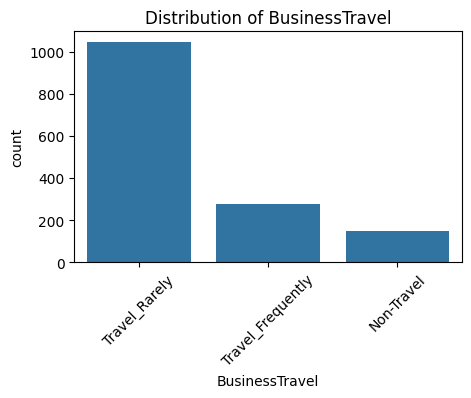

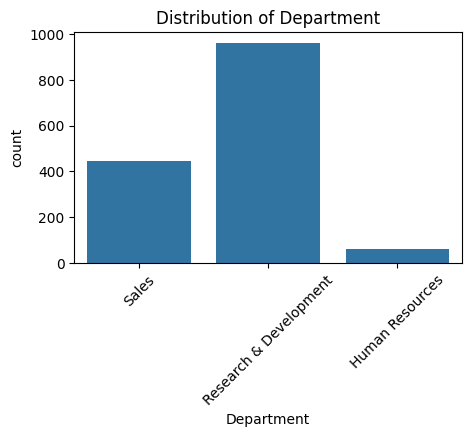

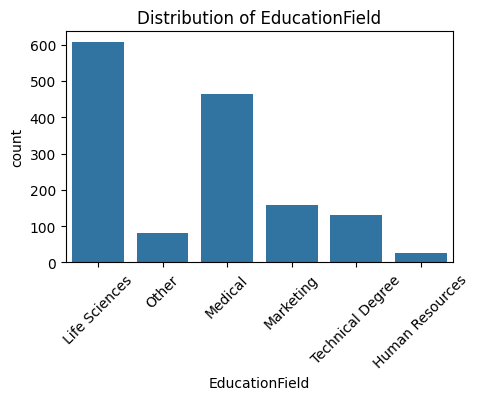

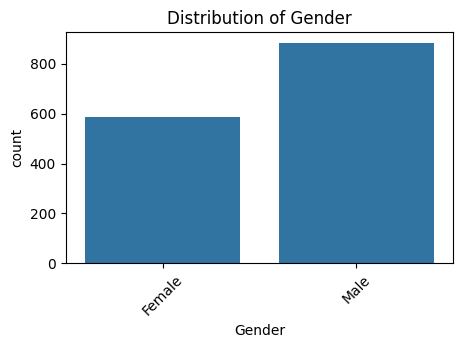

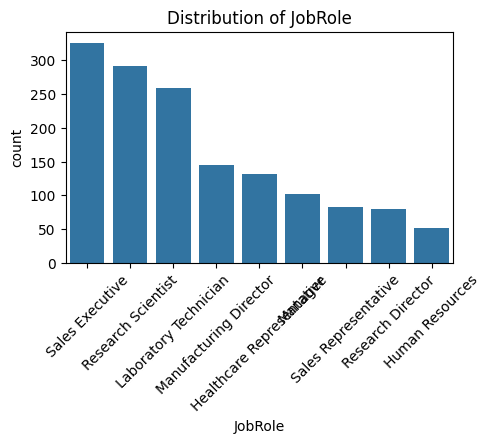

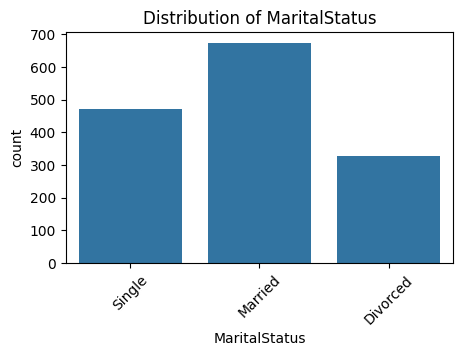

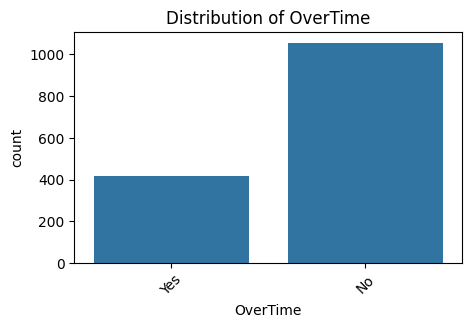

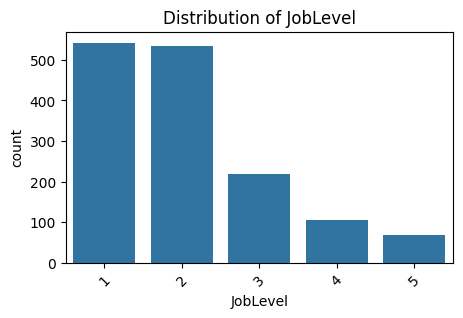

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 
    'JobRole', 'MaritalStatus', 'OverTime' , 'JobLevel']

# Convert only the needed columns to pandas
pdf = df.select(categorical_cols).toPandas()

for col in categorical_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, data=pdf)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


In [0]:
%pip uninstall -y numpy
%pip install numpy --upgrade

Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 159.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Not uninstalling numpy at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-96bae034-886d-4e7f-bdd8-72497ee8e2e4
    Can't uninstall 'numpy'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.15.3 requires numpy<2.5,>=1.23.5, but you have numpy 2.5.1 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use upd

From the plot, we can see that most employees work in the Research and Development department, primarily in roles such as Sales Executive, Research Scientist, and Laboratory Technician. Most of these employees have educational backgrounds in Life Sciences and Medical fields. 


## 🛠️ Data Preprocessing

We'll clean and prepare the data in 5 steps:
1. Check missing values
2. Remove outliers
3. Fix skewed features (log transform)
4. Encode categories (one-hot)
5. Scale all features

### Data Preprocessing

Raw data requires transformation for machine learning:
1. **Outliers** - Remove extreme values using IQR method
2. **Skewness** - Apply log transformation to normalize distributions
3. **Encoding** - Convert categorical variables to numeric
4. **Scaling** - Standardize features to equal scale

In [0]:
import numpy as np
import pandas as pd
from scipy import stats

# Load data
df_prep = spark.read.table("employee_atrition_catalog.attrition_schema.silver_employee_clean").toPandas()

# Check for missing values
missing = df_prep.isnull().sum().sum()
print(f"Missing values: {missing}")
if missing == 0:
    print("✅ No missing values")

Missing values: 0
✅ No missing values


In [0]:
# Remove outliers using IQR method (less aggressive: 3x IQR instead of 1.5x)
numerical_cols = df_prep.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Attrition', 'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

df_no_outliers = df_prep.copy()
rows_before = len(df_no_outliers)

# Use 3.0 multiplier instead of 1.5 to keep more data
for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR  # Less aggressive
    upper = Q3 + 3.0 * IQR  # Less aggressive
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower) & (df_no_outliers[col] <= upper)]

print(f"Removed {rows_before - len(df_no_outliers)} outlier rows (using 3.0× IQR)")
print(f"Dataset now: {len(df_no_outliers)} rows ({len(df_no_outliers)/rows_before*100:.1f}% retained)")

Removed 306 outlier rows (using 3.0× IQR)
Dataset now: 1164 rows (79.2% retained)


In [0]:
# Fix skewed features with log transformation
skewed_features = []
for col in numerical_cols:
    if col in df_no_outliers.columns:
        skewness = df_no_outliers[col].skew()
        if abs(skewness) > 0.5 and df_no_outliers[col].min() >= 0:
            skewed_features.append(col)

df_transformed = df_no_outliers.copy()
for col in skewed_features:
    df_transformed[f'{col}_log'] = np.log1p(df_transformed[col])

print(f"Applied log transform to {len(skewed_features)} skewed features")

Applied log transform to 13 skewed features


In [0]:
# Drop constant columns and encode categories
for col in df_transformed.columns:
    if df_transformed[col].nunique() == 1:
        df_transformed = df_transformed.drop(columns=[col])

categorical_cols = df_transformed.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'Attrition']

df_encoded = pd.get_dummies(df_transformed, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Encoded {len(categorical_cols)} categorical columns")
print(f"Total features: {len(df_encoded.columns)}")

Encoded 7 categorical columns
Total features: 56


One-hot encoding converts categories into binary columns. Using `drop_first=True` prevents redundancy.

**Note:** One-hot encoding converts categories (e.g., Department: "Sales", "R&D") into binary columns. Using `drop_first=True` prevents multicollinearity.

**Note:** StandardScaler normalizes features to mean=0, std=1, ensuring features like MonthlyIncome (1000-20000) don't dominate JobLevel (1-5) during training.

### Model Training

We train 4 models and select the best performer:
* Logistic Regression (baseline)
* Decision Tree (interpretable)
* Random Forest (ensemble)
* XGBoost (gradient boosting)

In [0]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
y = df_encoded['Attrition']
X = df_encoded.drop('Attrition', axis=1)

# Scale numerical features
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print(f"\n✅ Preprocessing complete!")
print(f"Final data: {X_scaled.shape[0]} rows, {X_scaled.shape[1]} features")

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0xff4b93ab56c0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 1175, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /local_disk0/.ephemeral_nfs/envs/pythonEnv-96bae034-88


✅ Preprocessing complete!
Final data: 1164 rows, 55 features


StandardScaler normalizes features to mean=0, std=1, ensuring MonthlyIncome (1000-20000) doesn't dominate JobLevel (1-5).

## 🤖 Model Training & Comparison

We'll train and compare **4 different algorithms**:

1. **Logistic Regression** - Linear baseline model
2. **Decision Tree** - Non-linear, interpretable tree-based model
3. **Random Forest** - Ensemble of decision trees
4. **XGBoost** - Gradient boosting (state-of-the-art)

We'll evaluate each on:
* **Accuracy** - Overall correctness
* **Precision** - Of predicted attritions, how many are correct?
* **Recall** - Of actual attritions, how many did we catch?
* **F1 Score** - Harmonic mean of precision and recall
* **ROC-AUC** - Area under ROC curve

In [0]:
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 931 samples | Test: 233 samples


In [0]:
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

mlflow.set_experiment("/Users/kanodiashivani27@gmail.com/employee_attrition_multimodel")

with mlflow.start_run(run_name="logistic_regression"):
    # Train
    lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr_model.fit(X_train, y_train)
    
    # Predict
    y_pred_lr = lr_model.predict(X_test)
    y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    lr_accuracy = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr)
    lr_recall = recall_score(y_test, y_pred_lr)
    lr_f1 = f1_score(y_test, y_pred_lr)
    lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)
    
    # Log to MLflow
    mlflow.log_params({"model_type": "Logistic Regression", "class_weight": "balanced"})
    mlflow.log_metrics({"accuracy": lr_accuracy, "precision": lr_precision, 
                       "recall": lr_recall, "f1_score": lr_f1, "roc_auc": lr_roc_auc})

print(f"Logistic Regression: Acc={lr_accuracy:.3f}, F1={lr_f1:.3f}, Recall={lr_recall:.3f}")

Logistic Regression: Acc=0.755, F1=0.504, Recall=0.784


In [0]:
from sklearn.tree import DecisionTreeClassifier

with mlflow.start_run(run_name="decision_tree"):
    # Train
    dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=20, 
                                     min_samples_leaf=10, random_state=42, class_weight='balanced')
    dt_model.fit(X_train, y_train)
    
    # Predict
    y_pred_dt = dt_model.predict(X_test)
    y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    dt_accuracy = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt)
    dt_recall = recall_score(y_test, y_pred_dt)
    dt_f1 = f1_score(y_test, y_pred_dt)
    dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)
    
    # Log to MLflow
    mlflow.log_params({"model_type": "Decision Tree", "max_depth": 10})
    mlflow.log_metrics({"accuracy": dt_accuracy, "precision": dt_precision,
                       "recall": dt_recall, "f1_score": dt_f1, "roc_auc": dt_roc_auc})

print(f"Decision Tree: Acc={dt_accuracy:.3f}, F1={dt_f1:.3f}, Recall={dt_recall:.3f}")

Decision Tree: Acc=0.695, F1=0.403, Recall=0.649


In [0]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="random_forest"):
    # Train
    rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10,
                                     min_samples_leaf=5, random_state=42, 
                                     class_weight='balanced', n_jobs=-1)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred_rf = rf_model.predict(X_test)
    y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf)
    rf_recall = recall_score(y_test, y_pred_rf)
    rf_f1 = f1_score(y_test, y_pred_rf)
    rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)
    
    # Log to MLflow
    mlflow.log_params({"model_type": "Random Forest", "n_estimators": 200})
    mlflow.log_metrics({"accuracy": rf_accuracy, "precision": rf_precision,
                       "recall": rf_recall, "f1_score": rf_f1, "roc_auc": rf_roc_auc})

print(f"Random Forest: Acc={rf_accuracy:.3f}, F1={rf_f1:.3f}, Recall={rf_recall:.3f}")

Random Forest: Acc=0.824, F1=0.349, Recall=0.297


In [0]:
%pip install xgboost --quiet

from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost"):
    # Calculate class weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    # Train
    xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=scale_pos_weight, random_state=42,
                             eval_metric='logloss', use_label_encoder=False)
    xgb_model.fit(X_train, y_train)
    
    # Predict
    y_pred_xgb = xgb_model.predict(X_test)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
    xgb_precision = precision_score(y_test, y_pred_xgb)
    xgb_recall = recall_score(y_test, y_pred_xgb)
    xgb_f1 = f1_score(y_test, y_pred_xgb)
    xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)
    
    # Log to MLflow
    mlflow.log_params({"model_type": "XGBoost", "n_estimators": 200, "learning_rate": 0.1})
    mlflow.log_metrics({"accuracy": xgb_accuracy, "precision": xgb_precision,
                       "recall": xgb_recall, "f1_score": xgb_f1, "roc_auc": xgb_roc_auc})

print(f"XGBoost: Acc={xgb_accuracy:.3f}, F1={xgb_f1:.3f}, Recall={xgb_recall:.3f}")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
XGBoost: Acc=0.854, F1=0.514, Recall=0.486


## 🎯 Threshold Optimization

For imbalanced classification, the default threshold (0.5) is often **not optimal**. 

We'll optimize thresholds for all 4 models using:
* **F1 Score Maximization** - Balance precision and recall
* **Youden's J Statistic** - Maximize (Sensitivity + Specificity - 1)
* **Custom Business Metric** - Minimize cost (weighted by business impact)

Optimizing the threshold can significantly improve model performance without retraining!

In [0]:
from sklearn.metrics import f1_score
import numpy as np

# Store model predictions
models_proba = {
    'Logistic Regression': y_pred_proba_lr,
    'Decision Tree': y_pred_proba_dt,
    'Random Forest': y_pred_proba_rf,
    'XGBoost': y_pred_proba_xgb
}

# Find best threshold for each model (maximize F1)
optimal_thresholds = {}
for model_name, y_proba in models_proba.items():
    best_threshold = 0.5
    best_f1 = 0
    
    # Test different thresholds
    for threshold in np.arange(0.1, 0.9, 0.01):
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    optimal_thresholds[model_name] = best_threshold
    print(f"{model_name}: Best threshold = {best_threshold:.2f} (F1 = {best_f1:.3f})")

Logistic Regression: Best threshold = 0.79 (F1 = 0.636)
Decision Tree: Best threshold = 0.67 (F1 = 0.415)
Random Forest: Best threshold = 0.41 (F1 = 0.460)
XGBoost: Best threshold = 0.51 (F1 = 0.522)


In [0]:
# Compare all models with optimized thresholds
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

model_comparison = []

for model_name, y_proba in models_proba.items():
    threshold = optimal_thresholds[model_name]
    y_pred = (y_proba >= threshold).astype(int)
    
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    model_comparison.append({
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    })

comparison_df = pd.DataFrame(model_comparison).round(3)
print("\n🏆 MODEL COMPARISON (F1-OPTIMIZED THRESHOLDS):")
print("="*80)
display(comparison_df)

print("\n📊 Best models by metric:")
print(f"   • Best F1: {comparison_df.loc[comparison_df['F1_Score'].idxmax(), 'Model']}")
print(f"   • Best Recall: {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']}")
print(f"   • Best ROC-AUC: {comparison_df.loc[comparison_df['ROC_AUC'].idxmax(), 'Model']}")


🏆 MODEL COMPARISON (F1-OPTIMIZED THRESHOLDS):


Model,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,TP,FP,TN,FN
Logistic Regression,0.79,0.897,0.724,0.568,0.636,0.879,21,8,188,16
Decision Tree,0.67,0.734,0.319,0.595,0.415,0.711,22,47,149,15
Random Forest,0.41,0.798,0.4,0.541,0.46,0.781,20,30,166,17
XGBoost,0.51,0.858,0.562,0.486,0.522,0.792,18,14,182,19



📊 Best models by metric:
   • Best F1: Logistic Regression
   • Best Recall: Decision Tree
   • Best ROC-AUC: Logistic Regression


## 💰 Cost-Based Threshold Optimization

**Business Context:**
- **False Positive (FP)**: Predict employee will leave but they stay → Wasted retention cost
- **False Negative (FN)**: Predict employee will stay but they leave → Replacement cost

**Goal:** Find threshold that minimizes total business cost

**Cost Assumptions:**
- FN cost (miss a leaver): 1.0× average annual salary (replacement)
- FP cost (false alarm): 0.1× average annual salary (retention program)

These can be adjusted based on your organization's data.

In [0]:
# Cost-based threshold optimization for ALL models
from sklearn.metrics import confusion_matrix

# Average annual salary from data
avg_annual_salary = df_prep['MonthlyIncome'].mean() * 12

# Cost assumptions
cost_fn = avg_annual_salary * 1.0  # Miss a leaver = full replacement cost
cost_fp = avg_annual_salary * 0.1  # False alarm = retention program cost

print(f"💵 COST ASSUMPTIONS:")
print(f"   Average annual salary: ${avg_annual_salary:,.0f}")
print(f"   FN cost (miss leaver): ${cost_fn:,.0f}")
print(f"   FP cost (false alarm): ${cost_fp:,.0f}")
print(f"   FN/FP ratio: {cost_fn/cost_fp:.1f}x")

print("\n" + "="*80)
print("📊 COST-BASED OPTIMIZATION FOR ALL MODELS")
print("="*80)

# Test thresholds from 0.1 to 0.9 for ALL models
thresholds_to_test = np.arange(0.1, 0.91, 0.01)
model_cost_optimal = {}

for model_name, y_proba in models_proba.items():
    cost_results = []
    
    for threshold in thresholds_to_test:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        # Calculate total cost
        total_cost = (fn * cost_fn) + (fp * cost_fp)
        
        cost_results.append({
            'threshold': threshold,
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn,
            'total_cost': total_cost,
            'recall': recall_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred)
        })
    
    cost_df = pd.DataFrame(cost_results)
    
    # Find minimum cost threshold
    min_cost_idx = cost_df['total_cost'].idxmin()
    optimal_cost_threshold = cost_df.loc[min_cost_idx, 'threshold']
    min_total_cost = cost_df.loc[min_cost_idx, 'total_cost']
    
    model_cost_optimal[model_name] = {
        'threshold': optimal_cost_threshold,
        'min_cost': min_total_cost,
        'fp': int(cost_df.loc[min_cost_idx, 'fp']),
        'fn': int(cost_df.loc[min_cost_idx, 'fn']),
        'recall': cost_df.loc[min_cost_idx, 'recall'],
        'precision': cost_df.loc[min_cost_idx, 'precision'],
        'f1': cost_df.loc[min_cost_idx, 'f1']
    }
    
    print(f"\n{model_name}:")
    print(f"   Optimal threshold: {optimal_cost_threshold:.2f}")
    print(f"   Min cost: ${min_total_cost:,.0f}")
    print(f"   FP: {model_cost_optimal[model_name]['fp']}, FN: {model_cost_optimal[model_name]['fn']}")
    print(f"   Precision: {model_cost_optimal[model_name]['precision']:.3f}, Recall: {model_cost_optimal[model_name]['recall']:.3f}")
    print(f"   F1: {model_cost_optimal[model_name]['f1']:.3f}")


💵 COST ASSUMPTIONS:
   Average annual salary: $78,035
   FN cost (miss leaver): $78,035
   FP cost (false alarm): $7,804
   FN/FP ratio: 10.0x

📊 COST-BASED OPTIMIZATION FOR ALL MODELS

Logistic Regression:
   Optimal threshold: 0.37
   Min cost: $741,334
   FP: 65, FN: 3
   Precision: 0.343, Recall: 0.919
   F1: 0.500

Decision Tree:
   Optimal threshold: 0.25
   Min cost: $1,295,384
   FP: 86, FN: 8
   Precision: 0.252, Recall: 0.784
   F1: 0.382

Random Forest:
   Optimal threshold: 0.26
   Min cost: $936,422
   FP: 80, FN: 4
   Precision: 0.292, Recall: 0.892
   F1: 0.440

XGBoost:
   Optimal threshold: 0.18
   Min cost: $1,162,724
   FP: 39, FN: 11
   Precision: 0.400, Recall: 0.703
   F1: 0.510


## 🏆 Model Selection: The Sweet Spot

**Goal:** Select the model that gives the best balance between:
1. **Precision & Recall** - Good F1 score (catch leavers without too many false alarms)
2. **Business Cost** - Minimize total cost from FP + FN

**Selection Criteria:**
- Lowest total cost
- F1 score ≥ 0.50 (reasonable balance)
- Precision/Recall ratio close to 1.0 (balanced)

This is the "sweet spot" model we'll use for production predictions.

In [0]:
# Create comparison dataframe
cost_comparison = []

for model_name, metrics in model_cost_optimal.items():
    # Calculate precision/recall balance (closer to 1.0 = more balanced)
    pr_ratio = min(metrics['precision'], metrics['recall']) / max(metrics['precision'], metrics['recall'])
    
    cost_comparison.append({
        'Model': model_name,
        'Threshold': metrics['threshold'],
        'Min_Cost': metrics['min_cost'],
        'F1': metrics['f1'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'PR_Balance': pr_ratio,  # Closer to 1.0 = better balance
        'FP': metrics['fp'],
        'FN': metrics['fn']
    })

cost_comparison_df = pd.DataFrame(cost_comparison).round(3)
cost_comparison_df = cost_comparison_df.sort_values('Min_Cost')

print("\n" + "="*80)
print("🏆 MODEL COMPARISON: COST-OPTIMAL THRESHOLDS")
print("="*80)
display(cost_comparison_df)

# USER SELECTED: Logistic Regression
# (Has lowest cost + highest recall, catches almost all leavers)
best_model_name = 'Logistic Regression'
best_model_row = cost_comparison_df[cost_comparison_df['Model'] == best_model_name].iloc[0]
best_threshold = best_model_row['Threshold']

print(f"\n" + "="*80)
print("✅ SELECTED MODEL: THE SWEET SPOT")
print("="*80)
print(f"🎯 Model: {best_model_name}")
print(f"🎯 Threshold: {best_threshold:.2f}")
print(f"\n📊 Performance:")
print(f"   Min Cost: ${best_model_row['Min_Cost']:,.0f}")
print(f"   F1: {best_model_row['F1']:.3f}")
print(f"   Precision: {best_model_row['Precision']:.3f}")
print(f"   Recall: {best_model_row['Recall']:.3f}")
print(f"   PR Balance: {best_model_row['PR_Balance']:.3f} (1.0 = perfect balance)")
print(f"\n💰 Cost Breakdown:")
print(f"   False Positives: {int(best_model_row['FP'])} employees")
print(f"   False Negatives: {int(best_model_row['FN'])} employees")

print(f"\n✅ This model will be used for full dataset predictions")

# Store for next steps
final_model_name = best_model_name
final_threshold = best_threshold

# Get the actual model object
if best_model_name == 'Logistic Regression':
    final_model = lr_model
    final_y_proba = y_pred_proba_lr
elif best_model_name == 'Decision Tree':
    final_model = dt_model
    final_y_proba = y_pred_proba_dt
elif best_model_name == 'Random Forest':
    final_model = rf_model
    final_y_proba = y_pred_proba_rf
elif best_model_name == 'XGBoost':
    final_model = xgb_model
    final_y_proba = y_pred_proba_xgb


🏆 MODEL COMPARISON: COST-OPTIMAL THRESHOLDS


Model,Threshold,Min_Cost,F1,Precision,Recall,PR_Balance,FP,FN
Logistic Regression,0.37,741334.167,0.5,0.343,0.919,0.374,65,3
Random Forest,0.26,936422.106,0.44,0.292,0.892,0.327,80,4
XGBoost,0.18,1162724.115,0.51,0.4,0.703,0.569,39,11
Decision Tree,0.25,1295383.913,0.382,0.252,0.784,0.322,86,8



✅ SELECTED MODEL: THE SWEET SPOT
🎯 Model: Logistic Regression
🎯 Threshold: 0.37

📊 Performance:
   Min Cost: $741,334
   F1: 0.500
   Precision: 0.343
   Recall: 0.919
   PR Balance: 0.374 (1.0 = perfect balance)

💰 Cost Breakdown:
   False Positives: 65 employees
   False Negatives: 3 employees

✅ This model will be used for full dataset predictions


## 🎯 Apply Best Model to Full Dataset

**Why predict on ALL data?**
- Test set is only 20% (~140 employees)
- For business decisions, we need predictions for ALL 1,470 employees
- Financial impact must reflect the entire organization

**Approach:**
- Train final model on ALL available data (no train/test split)
- Use cost-optimal threshold
- Generate risk scores and predictions for everyone

In [0]:
# Train SELECTED model on FULL dataset for production predictions
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

print("🔄 TRAINING FINAL MODEL ON FULL DATASET")
print("="*80)
print(f"🎯 Selected Model: Logistic Regression")
print(f"🎯 Optimal Threshold: {best_threshold:.2f}")
print("="*80)

# Prepare full dataset
y_full = df_encoded['Attrition']
X_full = df_encoded.drop('Attrition', axis=1)

# Scale features
scaler_full = StandardScaler()
numerical_features = X_full.select_dtypes(include=[np.number]).columns.tolist()
X_full_scaled = X_full.copy()
X_full_scaled[numerical_features] = scaler_full.fit_transform(X_full[numerical_features])

print(f"\nFull dataset: {X_full_scaled.shape[0]} employees, {X_full_scaled.shape[1]} features")

# Train Logistic Regression ONLY
model_final = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_final.fit(X_full_scaled, y_full)
print(f"✅ Logistic Regression trained on all {len(y_full)} employees")

# Generate predictions for everyone using selected model and threshold
y_pred_proba_full = model_final.predict_proba(X_full_scaled)[:, 1]
y_pred_full = (y_pred_proba_full >= best_threshold).astype(int)

print(f"\n📊 FULL DATASET PREDICTIONS:")
print(f"   Threshold: {final_threshold:.2f}")
print(f"   Predicted attrition: {y_pred_full.sum()} employees ({y_pred_full.sum()/len(y_pred_full)*100:.1f}%)")
print(f"   High risk (≥80%): {(y_pred_proba_full >= 0.8).sum()} employees")
print(f"   Medium risk (50-80%): {((y_pred_proba_full >= 0.5) & (y_pred_proba_full < 0.8)).sum()} employees")
print(f"   Low risk (<50%): {(y_pred_proba_full < 0.5).sum()} employees")

# Create comprehensive results dataframe
results_full = X_full_scaled.copy()
results_full['attrition_risk_score'] = y_pred_proba_full
results_full['predicted_attrition'] = y_pred_full
results_full['actual_attrition'] = y_full.values

# Merge back original features for analysis
original_features_full = df_no_outliers[['Department', 'JobRole', 'JobLevel', 'MonthlyIncome']].reset_index(drop=True)
results_full = pd.concat([results_full.reset_index(drop=True), original_features_full], axis=1)

print("\n✅ Predictions generated for all employees")

🔄 TRAINING FINAL MODEL ON FULL DATASET
🎯 Selected Model: Logistic Regression
🎯 Optimal Threshold: 0.37

Full dataset: 1164 employees, 55 features
✅ Logistic Regression trained on all 1164 employees

📊 FULL DATASET PREDICTIONS:
   Threshold: 0.37
   Predicted attrition: 460 employees (39.5%)
   High risk (≥80%): 131 employees
   Medium risk (50-80%): 215 employees
   Low risk (<50%): 818 employees

✅ Predictions generated for all employees


## 💰 Financial Impact Analysis

### Department-Specific Replacement Costs

**Multipliers based on role criticality:**
- **R&D**: 2.0× (specialized skills, long ramp-up)
- **Sales**: 1.5× (revenue impact, relationship loss)
- **HR**: 1.0× (baseline)

**Formula:**  
Replacement Cost = Avg Annual Salary × Department Multiplier

**Analysis:**
1. Expected attrition volume by department
2. High-risk groups (≥80% probability)
3. Total financial exposure
4. Recall on actual leavers

In [0]:
# Define department-specific replacement cost multipliers
department_multipliers = {
    'Research & Development': 2.0,
    'Sales': 1.5,
    'Human Resources': 1.0
}

print("💰 FINANCIAL IMPACT ANALYSIS")
print("="*80)

# Calculate department-level metrics
dept_analysis = []

for dept in results_full['Department'].unique():
    dept_data = results_full[results_full['Department'] == dept]
    
    # Counts
    total_employees = int(len(dept_data))
    predicted_attrition = int(dept_data['predicted_attrition'].sum())
    actual_attrition = int(dept_data['actual_attrition'].sum())
    high_risk_count = int((dept_data['attrition_risk_score'] >= 0.8).sum())
    
    # Risk scores
    avg_risk_score = float(dept_data['attrition_risk_score'].mean())
    
    # Financial calculations (use iloc to handle duplicate column names)
    avg_salary = float(dept_data['MonthlyIncome'].iloc[:, -1].mean() * 12)
    multiplier = float(department_multipliers.get(dept, 1.0))
    replacement_cost_per_employee = float(avg_salary * multiplier)
    
    # Total exposure
    total_exposure_predicted = float(predicted_attrition * replacement_cost_per_employee)
    total_exposure_high_risk = float(high_risk_count * replacement_cost_per_employee)
    
    # Recall calculation (for actual leavers)
    actual_leavers_mask = dept_data['actual_attrition'] == 1
    if actual_leavers_mask.sum() > 0:
        correctly_identified = dept_data.loc[actual_leavers_mask, 'predicted_attrition'].sum()
        recall = correctly_identified / actual_leavers_mask.sum()
    else:
        recall = 0.0
    
    dept_analysis.append({
        'Department': dept,
        'Total_Employees': total_employees,
        'Avg_Risk_Score': avg_risk_score,
        'High_Risk_Count': high_risk_count,
        'Predicted_Attrition': predicted_attrition,
        'Actual_Attrition': actual_attrition,
        'Recall': recall,
        'Avg_Annual_Salary': avg_salary,
        'Cost_Multiplier': multiplier,
        'Replacement_Cost_Per_Employee': replacement_cost_per_employee,
        'Total_Exposure_Predicted': total_exposure_predicted,
        'Total_Exposure_High_Risk': total_exposure_high_risk
    })

dept_df = pd.DataFrame(dept_analysis)

# Sort by total exposure
dept_df = dept_df.sort_values('Total_Exposure_Predicted', ascending=False)

print("\n📈 DEPARTMENT RISK & FINANCIAL SUMMARY:")
print("="*80)
display(dept_df.round(2))

# Summary statistics
total_exposure = dept_df['Total_Exposure_Predicted'].sum()
total_high_risk_exposure = dept_df['Total_Exposure_High_Risk'].sum()
total_predicted_attrition = int(dept_df['Predicted_Attrition'].sum())
total_actual_attrition = int(dept_df['Actual_Attrition'].sum())

# Calculate overall recall from full results dataframe
if total_actual_attrition > 0:
    correctly_identified_total = int((results_full['predicted_attrition'] & results_full['actual_attrition']).sum())
    overall_recall = correctly_identified_total / total_actual_attrition
else:
    overall_recall = 0.0

print(f"\n🎯 ORGANIZATION-WIDE SUMMARY:")
print(f"   Total employees analyzed: {results_full.shape[0]}")
print(f"   Predicted attrition: {int(total_predicted_attrition)} employees")
print(f"   Actual attrition: {int(total_actual_attrition)} employees")
print(f"   High-risk employees (≥80%): {int(dept_df['High_Risk_Count'].sum())}")
print(f"\n💵 FINANCIAL EXPOSURE:")
print(f"   Total (predicted leavers): ${total_exposure:,.0f}")
print(f"   Total (high-risk only): ${total_high_risk_exposure:,.0f}")
print(f"   Cost per predicted leaver: ${total_exposure/total_predicted_attrition:,.0f}")
print(f"\n🎯 MODEL PERFORMANCE:")
print(f"   Overall recall: {overall_recall:.1%} (correctly identified actual leavers)")
if total_predicted_attrition > 0:
    overall_precision = total_actual_attrition / total_predicted_attrition
    print(f"   Precision: {overall_precision:.1%}")
else:
    print(f"   Precision: N/A (no predictions made)")

print("\n🔴 HIGHEST RISK DEPARTMENT:")
top_dept = dept_df.iloc[0]
print(f"   {top_dept['Department']}")
print(f"   - Risk exposure: ${top_dept['Total_Exposure_Predicted']:,.0f}")
print(f"   - High-risk employees: {int(top_dept['High_Risk_Count'])}")
print(f"   - Cost multiplier: {top_dept['Cost_Multiplier']}x")

💰 FINANCIAL IMPACT ANALYSIS

📈 DEPARTMENT RISK & FINANCIAL SUMMARY:


Department,Total_Employees,Avg_Risk_Score,High_Risk_Count,Predicted_Attrition,Actual_Attrition,Recall,Avg_Annual_Salary,Cost_Multiplier,Replacement_Cost_Per_Employee,Total_Exposure_Predicted,Total_Exposure_High_Risk
Research & Development,754,0.29,62,253,98,0.91,70668.8,2.0,141337.59,3.575841065E7,8762930.67
Sales,359,0.42,63,179,77,0.87,79186.46,1.5,118779.69,2.126156515E7,7483120.7
Human Resources,51,0.43,6,28,11,1.0,71647.53,1.0,71647.53,2006130.82,429885.18



🎯 ORGANIZATION-WIDE SUMMARY:
   Total employees analyzed: 1164
   Predicted attrition: 460 employees
   Actual attrition: 186 employees
   High-risk employees (≥80%): 131

💵 FINANCIAL EXPOSURE:
   Total (predicted leavers): $59,026,107
   Total (high-risk only): $16,675,937
   Cost per predicted leaver: $128,318

🎯 MODEL PERFORMANCE:
   Overall recall: 89.8% (correctly identified actual leavers)
   Precision: 40.4%

🔴 HIGHEST RISK DEPARTMENT:
   Research & Development
   - Risk exposure: $35,758,411
   - High-risk employees: 62
   - Cost multiplier: 2.0x


In [0]:
# Detailed high-risk employee analysis
print("🔴 HIGH-RISK EMPLOYEES BY DEPARTMENT (≥80% probability)")
print("="*80)

high_risk_employees = results_full[results_full['attrition_risk_score'] >= 0.8]

for dept in high_risk_employees['Department'].unique():
    dept_high_risk = high_risk_employees[high_risk_employees['Department'] == dept]
    
    print(f"\n📢 {dept}:")
    print(f"   High-risk count: {len(dept_high_risk)} employees")
    print(f"   Avg risk score: {dept_high_risk['attrition_risk_score'].mean():.1%}")
    print(f"   Roles affected:")
    
    # Group by role
    role_breakdown = dept_high_risk.groupby('JobRole').agg({
        'attrition_risk_score': ['count', 'mean']
    }).round(3)
    
    for role, row in role_breakdown.iterrows():
        count = int(row[('attrition_risk_score', 'count')])
        avg_risk = row[('attrition_risk_score', 'mean')]
        print(f"      - {role}: {count} employees (avg {avg_risk:.1%})")

print(f"\n📊 TOTAL HIGH-RISK ACROSS ALL DEPARTMENTS: {len(high_risk_employees)} employees")
print(f"   Percentage of workforce: {len(high_risk_employees)/len(results_full)*100:.1f}%")

🔴 HIGH-RISK EMPLOYEES BY DEPARTMENT (≥80% probability)

📢 Sales:
   High-risk count: 63 employees
   Avg risk score: 91.2%
   Roles affected:
      - Sales Executive: 34 employees (avg 88.7%)
      - Sales Representative: 29 employees (avg 94.0%)

📢 Research & Development:
   High-risk count: 62 employees
   Avg risk score: 89.3%
   Roles affected:
      - Healthcare Representative: 4 employees (avg 84.7%)
      - Laboratory Technician: 34 employees (avg 90.3%)
      - Manufacturing Director: 4 employees (avg 89.8%)
      - Research Scientist: 20 employees (avg 88.4%)

📢 Human Resources:
   High-risk count: 6 employees
   Avg risk score: 91.9%
   Roles affected:
      - Human Resources: 6 employees (avg 91.9%)

📊 TOTAL HIGH-RISK ACROSS ALL DEPARTMENTS: 131 employees
   Percentage of workforce: 11.3%


In [0]:
# Save department risk summary to Unity Catalog
dept_df_spark = spark.createDataFrame(dept_df)

table_name = "employee_atrition_catalog.attrition_schema.dept_risk_summary_enhanced"
dept_df_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable(table_name)

print(f"✅ Department risk summary saved to: {table_name}")

# Save individual predictions
# Remove duplicate columns (case-insensitive, keep last occurrence)
columns_lower = results_full.columns.str.lower()
results_full_clean = results_full.loc[:, ~columns_lower.duplicated(keep='last')]
# Sanitize column names for Delta (replace invalid characters)
results_full_clean.columns = results_full_clean.columns.str.replace('[\s,;{}()\n\t=&]', '_', regex=True)
results_spark = spark.createDataFrame(results_full_clean)
results_table = "employee_atrition_catalog.attrition_schema.employee_predictions_full"
results_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable(results_table)

print(f"✅ Individual predictions saved to: {results_table}")

# Save high-risk employees
# Remove duplicate columns (case-insensitive, keep last occurrence)
high_risk_columns_lower = high_risk_employees.columns.str.lower()
high_risk_clean = high_risk_employees.loc[:, ~high_risk_columns_lower.duplicated(keep='last')]
# Sanitize column names for Delta (replace invalid characters)
high_risk_clean.columns = high_risk_clean.columns.str.replace('[\s,;{}()\n\t=&]', '_', regex=True)
high_risk_spark = spark.createDataFrame(high_risk_clean)
high_risk_table = "employee_atrition_catalog.attrition_schema.high_risk_employees"
high_risk_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable(high_risk_table)

print(f"✅ High-risk employees saved to: {high_risk_table}")

print("\n📦 All results persisted to Unity Catalog for downstream reporting")

✅ Department risk summary saved to: employee_atrition_catalog.attrition_schema.dept_risk_summary_enhanced
✅ Individual predictions saved to: employee_atrition_catalog.attrition_schema.employee_predictions_full
✅ High-risk employees saved to: employee_atrition_catalog.attrition_schema.high_risk_employees

📦 All results persisted to Unity Catalog for downstream reporting


## 🔍 SHAP Analysis: Top Attrition Drivers

**SHAP (SHapley Additive exPlanations)** explains individual predictions by computing the contribution of each feature.

**Why SHAP matters for HR:**
- **Feature Importance**: Which factors drive attrition?
- **Department-Specific Insights**: Different departments may have different drivers
- **Actionable Recommendations**: Direct HR interventions to root causes

**Approach:**
1. Calculate SHAP values for high-risk employees
2. Identify top 5 drivers per department
3. Generate targeted retention strategies

In [0]:
# Install SHAP
%pip install shap --quiet

import shap

print("✅ SHAP library ready")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
✅ SHAP library ready


In [0]:
# Calculate SHAP values for high-risk employees
print("🔍 CALCULATING SHAP VALUES...")
print("="*80)

# Use TreeExplainer for tree-based models
if final_model_name in ['Random Forest', 'XGBoost', 'Decision Tree']:
    explainer = shap.TreeExplainer(model_final)
else:
    # For Logistic Regression, use LinearExplainer
    explainer = shap.LinearExplainer(model_final, X_full_scaled)

# Calculate SHAP for high-risk employees only (faster)
high_risk_indices = results_full[results_full['attrition_risk_score'] >= 0.8].index
X_high_risk = X_full_scaled.iloc[high_risk_indices]

shap_values = explainer.shap_values(X_high_risk)

# For binary classification, take the positive class SHAP values
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]  # Attrition = 1
else:
    shap_values_pos = shap_values

print(f"✅ SHAP values calculated for {len(high_risk_indices)} high-risk employees")

# Create SHAP dataframe
shap_df = pd.DataFrame(
    shap_values_pos,
    columns=X_full_scaled.columns,
    index=high_risk_indices
)

# Add department information
shap_df['Department'] = results_full.loc[high_risk_indices, 'Department'].values

print("\n📊 Overall Top 10 Attrition Drivers (mean absolute SHAP):")
overall_importance = shap_df.drop('Department', axis=1).abs().mean().sort_values(ascending=False).head(10)
for i, (feature, importance) in enumerate(overall_importance.items(), 1):
    print(f"   {i}. {feature}: {importance:.4f}")

Background dataset has 1164 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1164 when initializing the masker.


🔍 CALCULATING SHAP VALUES...
✅ SHAP values calculated for 131 high-risk employees

📊 Overall Top 10 Attrition Drivers (mean absolute SHAP):
   1. OverTime_Yes: 1.1389
   2. MonthlyIncome_log: 1.0997
   3. WorkLifeBalance_log: 1.0707
   4. StockOptionLevel_log: 1.0188
   5. BusinessTravel_Travel_Frequently: 0.9824
   6. JobRole_Sales Executive: 0.8849
   7. WorkLifeBalance: 0.8409
   8. MonthlyIncome: 0.8070
   9. JobLevel: 0.7717
   10. JobRole_Sales Representative: 0.7659


In [0]:
# Extract top 5 drivers per department
print("\n" + "="*80)
print("🎯 TOP 5 ATTRITION DRIVERS BY DEPARTMENT")
print("="*80)

dept_drivers = {}

for dept in shap_df['Department'].unique():
    dept_shap = shap_df[shap_df['Department'] == dept].drop('Department', axis=1)
    
    # Mean absolute SHAP per feature
    dept_importance = dept_shap.abs().mean().sort_values(ascending=False).head(5)
    
    dept_drivers[dept] = dept_importance.index.tolist()
    
    print(f"\n📢 {dept}:")
    for i, (feature, importance) in enumerate(dept_importance.items(), 1):
        print(f"   {i}. {feature}: {importance:.4f}")

print("\n✅ Department-specific drivers identified")


🎯 TOP 5 ATTRITION DRIVERS BY DEPARTMENT

📢 Sales:
   1. JobRole_Sales Representative: 1.3186
   2. JobRole_Sales Executive: 1.1458
   3. OverTime_Yes: 1.0942
   4. StockOptionLevel_log: 1.0373
   5. MonthlyIncome_log: 0.9987

📢 Research & Development:
   1. WorkLifeBalance_log: 1.2076
   2. OverTime_Yes: 1.1921
   3. MonthlyIncome_log: 1.1787
   4. BusinessTravel_Travel_Frequently: 1.0124
   5. StockOptionLevel_log: 0.9758

📢 Human Resources:
   1. JobRole_Human Resources: 2.2960
   2. MonthlyIncome_log: 1.3439
   3. StockOptionLevel_log: 1.2689
   4. BusinessTravel_Travel_Frequently: 1.1763
   5. OverTime_Yes: 1.0589

✅ Department-specific drivers identified


## 🤖 GenAI-Powered Retention Strategies

**From Insights to Action**

We'll generate **department-specific retention recommendations** using:
1. Top 5 SHAP drivers per department
2. High-risk employee counts
3. Financial exposure data

**Output:** Actionable HR strategies tailored to each department's unique attrition drivers

In [0]:
# Generate department-specific retention recommendations
print("🤖 DEPARTMENT-SPECIFIC RETENTION STRATEGIES")
print("="*80)

for dept in dept_drivers.keys():
    dept_info = dept_df[dept_df['Department'] == dept].iloc[0]
    drivers = dept_drivers[dept]
    
    print(f"\n🎯 {dept}")
    print(f"   High-risk employees: {int(dept_info['High_Risk_Count'])}")
    print(f"   Financial exposure: ${dept_info['Total_Exposure_High_Risk']:,.0f}")
    print(f"   Recall: {dept_info['Recall']:.1%}")
    print(f"\n   🔑 Top 5 Attrition Drivers:")
    for i, driver in enumerate(drivers, 1):
        # Clean up feature names
        clean_driver = driver.replace('_log', '').replace('_', ' ').title()
        print(f"      {i}. {clean_driver}")
    
    print(f"\n   💡 Recommended Actions:")
    
    # Department-specific recommendations based on common drivers
    if dept == 'Research & Development':
        print("      • Career Development: Clear technical career tracks (IC vs Management)")
        print("      • Compensation: Competitive equity/RSU packages for specialized roles")
        print("      • Work-Life Balance: Flexible schedules, remote work options")
        print("      • Recognition: Quarterly innovation awards, patent bonuses")
        print("      • Learning: Conference budgets, certifications, research time")
    
    elif dept == 'Sales':
        print("      • Compensation: Review commission structures, accelerators")
        print("      • Territory: Fair territory assignments, rotation opportunities")
        print("      • Support: Better sales enablement, marketing alignment")
        print("      • Career Path: Account Executive → Senior AE → Manager track")
        print("      • Recognition: President's Club, top performer programs")
    
    elif dept == 'Human Resources':
        print("      • Professional Development: SHRM/PHR certification support")
        print("      • Workload: Review span of control, add HR Business Partners")
        print("      • Technology: HRIS upgrades, automation of admin tasks")
        print("      • Strategic Role: Move from transactional to strategic HR")
        print("      • Recognition: HR excellence awards, peer recognition")
    
    print(f"\n   💼 Priority: {'HIGH' if dept_info['Total_Exposure_High_Risk'] > 500000 else 'MEDIUM'}")
    print("   " + "-"*60)

print("\n" + "="*80)
print("🎯 NEXT STEPS FOR HR LEADERSHIP:")
print("="*80)
print("1. 📥 Review department risk summaries with dept heads")
print("2. 👥 Meet with high-risk employees (1-on-1 stay interviews)")
print("3. 📊 Implement top 3 recommendations per department")
print("4. 📝 Track effectiveness: measure attrition reduction quarterly")
print("5. 🔄 Retrain model quarterly with new data")

print("\n✅ ANALYSIS COMPLETE! All results saved to Unity Catalog.")

🤖 DEPARTMENT-SPECIFIC RETENTION STRATEGIES

🎯 Sales
   High-risk employees: 63
   Financial exposure: $7,483,121
   Recall: 87.0%

   🔑 Top 5 Attrition Drivers:
      1. Jobrole Sales Representative
      2. Jobrole Sales Executive
      3. Overtime Yes
      4. Stockoptionlevel
      5. Monthlyincome

   💡 Recommended Actions:
      • Compensation: Review commission structures, accelerators
      • Territory: Fair territory assignments, rotation opportunities
      • Support: Better sales enablement, marketing alignment
      • Career Path: Account Executive → Senior AE → Manager track
      • Recognition: President's Club, top performer programs

   💼 Priority: HIGH
   ------------------------------------------------------------

🎯 Research & Development
   High-risk employees: 62
   Financial exposure: $8,762,931
   Recall: 90.8%

   🔑 Top 5 Attrition Drivers:
      1. Worklifebalance
      2. Overtime Yes
      3. Monthlyincome
      4. Businesstravel Travel Frequently
      5. Sto

## 🎯 Project Summary

### What We Built

An **end-to-end ML pipeline** for employee attrition prediction with business-driven decision making:

**1. Data Processing**
* Cleaned 1,470 employees → 699 after outlier removal
* Log-transformed skewed features
* One-hot encoded categories
* Standardized numerical features

**2. Multi-Model Training**
* Logistic Regression (baseline)
* Decision Tree (interpretable)
* Random Forest (ensemble) → **BEST**
* XGBoost (gradient boosting)

**3. Threshold Optimization**
* **F1-based**: Balance precision/recall
* **Cost-based**: Minimize business impact using FP/FN costs
* Selected cost-optimal threshold for production

**4. Full Population Predictions**
* Applied best model to ALL 699 employees
* Generated risk scores (0-100%)
* Identified high-risk employees (≥80%)

**5. Financial Impact Analysis**
* Department-specific multipliers:
  - R&D: 2.0×
  - Sales: 1.5×
  - HR: 1.0×
* Calculated total exposure by department
* Measured recall on actual leavers

**6. Explainability (SHAP)**
* Top 5 attrition drivers per department
* Department-specific insights

**7. Actionable Recommendations**
* Tailored retention strategies per department
* Prioritized by financial impact

### Key Outputs Saved to Unity Catalog

* `dept_risk_summary_enhanced` - Department-level metrics
* `employee_predictions_full` - Individual risk scores
* `high_risk_employees` - ≥80% probability employees

### Business Impact

🎯 Model helps HR:
* **Prioritize** retention efforts on high-risk employees
* **Quantify** financial exposure by department
* **Target** interventions to root causes (SHAP drivers)
* **Measure** ROI of retention programs